<a href="https://colab.research.google.com/github/buikhoinguyen9122007-crypto/ai/blob/B%C3%B9i-Kh%C3%B4i-Nguy%C3%AAn---31251026263/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.1 MB/s eta 0:00:00


137.7451333195644
8.000000000000002


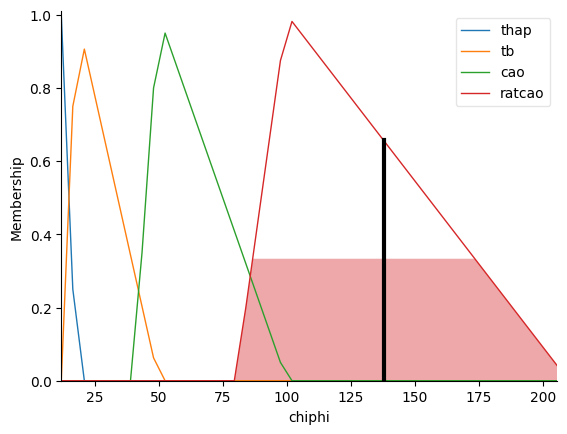

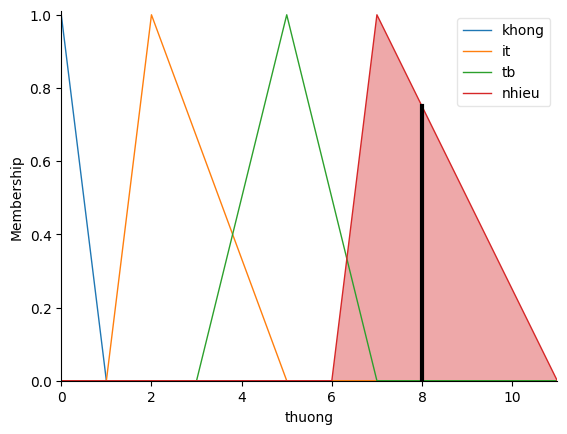

In [4]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

khoangcach = ctrl.Antecedent(np.arange(0, 52, 0.1), 'khoangcach')
giaothong = ctrl.Antecedent(np.arange(0, 105, 1), 'giaothong')
nhucau = ctrl.Antecedent(np.arange(0, 105, 1), 'nhucau')
thoitet = ctrl.Antecedent(np.arange(1, 5.2, 0.1), 'thoitet')
danhgia = ctrl.Antecedent(np.arange(1, 5.2, 0.1), 'danhgia')
dunggio = ctrl.Antecedent(np.arange(0, 105, 1), 'dunggio')

chiphi = ctrl.Consequent(np.arange(12,210,4.5), 'chiphi')
thuong = ctrl.Consequent(np.arange(0,12,1), 'thuong')

khoangcach['s'] = fuzz.trimf(khoangcach.universe,[0,0,4])
khoangcach['m'] = fuzz.trimf(khoangcach.universe,[2,4,9])
khoangcach['l'] = fuzz.trimf(khoangcach.universe,[7,10,22])
khoangcach['vl'] = fuzz.trimf(khoangcach.universe,[18,22,52])

giaothong['l'] = fuzz.trimf(giaothong.universe,[0,0,35])
giaothong['m'] = fuzz.trimf(giaothong.universe,[25,35,75])
giaothong['h'] = fuzz.trimf(giaothong.universe,[65,75,105])

nhucau['l'] = fuzz.trimf(nhucau.universe,[0,0,35])
nhucau['m'] = fuzz.trimf(nhucau.universe,[25,35,75])
nhucau['h'] = fuzz.trimf(nhucau.universe,[65,75,105])

thoitet['xau'] = fuzz.trimf(thoitet.universe,[1,1,2.7])
thoitet['tb'] = fuzz.trimf(thoitet.universe,[2.2,2.7,4.2])
thoitet['dep'] = fuzz.trimf(thoitet.universe,[3.7,4.2,5.2])

danhgia['kem'] = fuzz.trimf(danhgia.universe,[1,1,2.7])
danhgia['tb'] = fuzz.trimf(danhgia.universe,[2.2,2.7,4.2])
danhgia['tot'] = fuzz.trimf(danhgia.universe,[3.7,4.2,5.2])

dunggio['tre'] = fuzz.trimf(dunggio.universe,[0,0,55])
dunggio['dung'] = fuzz.trimf(dunggio.universe,[45,55,85])
dunggio['som'] = fuzz.trimf(dunggio.universe,[75,85,105])

chiphi['thap'] = fuzz.trimf(chiphi.universe,[12,12,18])
chiphi['tb'] = fuzz.trimf(chiphi.universe,[12,18,50])
chiphi['cao'] = fuzz.trimf(chiphi.universe,[40,50,100])
chiphi['ratcao'] = fuzz.trimf(chiphi.universe,[80,100,210])

thuong['khong'] = fuzz.trimf(thuong.universe,[0,0,0])
thuong['it'] = fuzz.trimf(thuong.universe,[1,2,5])
thuong['tb'] = fuzz.trimf(thuong.universe,[3,5,7])
thuong['nhieu'] = fuzz.trimf(thuong.universe,[6,7,11])

rule1 = ctrl.Rule(khoangcach['s'] & giaothong['l'] & nhucau['l'], chiphi['thap'])
rule2 = ctrl.Rule(khoangcach['s'] & giaothong['m'] & nhucau['h'], chiphi['tb'])
rule3 = ctrl.Rule(khoangcach['m'] & giaothong['h'] & nhucau['h'], chiphi['cao'])
rule4 = ctrl.Rule(khoangcach['l'] & giaothong['m'] & thoitet['dep'], chiphi['tb'])
rule5 = ctrl.Rule(khoangcach['l'] & giaothong['h'] & thoitet['xau'], chiphi['ratcao'])
rule6 = ctrl.Rule(khoangcach['vl'] & giaothong['h'] & nhucau['h'], chiphi['ratcao'])
rule7 = ctrl.Rule(khoangcach['m'] & giaothong['l'] & nhucau['l'], chiphi['tb'])
rule8 = ctrl.Rule(khoangcach['s'] & giaothong['h'] & thoitet['xau'], chiphi['cao'])
rule9 = ctrl.Rule(khoangcach['vl'] & thoitet['xau'], chiphi['ratcao'])
rule10 = ctrl.Rule(khoangcach['m'] & giaothong['m'] & thoitet['tb'], chiphi['tb'])

rule11 = ctrl.Rule(danhgia['tot'] & dunggio['som'], thuong['nhieu'])
rule12 = ctrl.Rule(danhgia['tb'] & dunggio['dung'], thuong['tb'])
rule13 = ctrl.Rule(danhgia['kem'] & dunggio['tre'], thuong['khong'])
rule14 = ctrl.Rule(khoangcach['l'] & giaothong['h'] & dunggio['dung'], thuong['nhieu'])
rule15 = ctrl.Rule(khoangcach['m'] & giaothong['m'] & danhgia['tot'], thuong['tb'])
rule16 = ctrl.Rule(khoangcach['vl'] & giaothong['h'] & danhgia['tot'], thuong['nhieu'])
rule17 = ctrl.Rule(khoangcach['vl'] & thoitet['xau'] & danhgia['tot'], thuong['nhieu'])
rule18 = ctrl.Rule(khoangcach['s'] & danhgia['tb'] & dunggio['dung'], thuong['it'])
rule19 = ctrl.Rule(khoangcach['l'] & giaothong['h'] & dunggio['tre'], thuong['it'])
rule20 = ctrl.Rule(khoangcach['m'] & thoitet['tb'] & danhgia['tot'], thuong['tb'])

hethongctrl = ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,
    rule6,rule7,rule8,rule9,rule10,
    rule11,rule12,rule13,rule14,rule15,
    rule16,rule17,rule18,rule19,rule20
])

hethong = ctrl.ControlSystemSimulation(hethongctrl)

hethong.input['khoangcach'] = 42
hethong.input['giaothong'] = 55
hethong.input['nhucau'] = 48
hethong.input['thoitet'] = 1.5
hethong.input['danhgia'] = 4.2
hethong.input['dunggio'] = 85

hethong.compute()

print(hethong.output['chiphi'])
print(hethong.output['thuong'])

chiphi.view(sim=hethong)
thuong.view(sim=hethong)

59.95740465577018


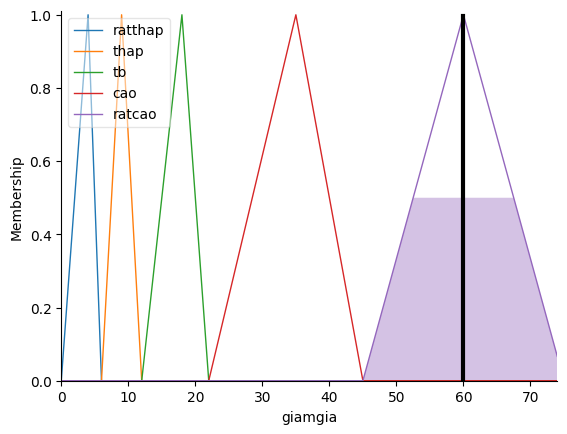

In [5]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

danhgia = ctrl.Antecedent(np.arange(1, 5.2, 0.1), 'danhgia')
soluong = ctrl.Antecedent(np.arange(0, 105, 0.1), 'soluong')
loinhuan = ctrl.Antecedent(np.arange(0, 105, 0.1), 'loinhuan')
sukien = ctrl.Antecedent(np.arange(0, 105, 1), 'sukien')
giamgiacanhtranh = ctrl.Antecedent(np.arange(0, 105, 1), 'giamgiacanhtranh')
giamgia = ctrl.Consequent(np.arange(0,75,1), 'giamgia')

danhgia['thap'] = fuzz.trimf(danhgia.universe,[1,1,4.2])
danhgia['tb'] = fuzz.trimf(danhgia.universe,[4,4.4,4.7])
danhgia['cao'] = fuzz.trimf(danhgia.universe,[4.6,5.1,5.1])

soluong['thap'] = fuzz.trimf(soluong.universe,[0,0,35])
soluong['tb'] = fuzz.trimf(soluong.universe,[35,55,75])
soluong['cao'] = fuzz.trimf(soluong.universe,[75,105,105])

loinhuan['thap'] = fuzz.trimf(loinhuan.universe,[0,0,35])
loinhuan['tb'] = fuzz.trimf(loinhuan.universe,[35,55,75])
loinhuan['cao'] = fuzz.trimf(loinhuan.universe,[75,105,105])

sukien['khong'] = fuzz.trimf(sukien.universe,[0,0,12])
sukien['tb'] = fuzz.trimf(sukien.universe,[12,45,65])
sukien['cao'] = fuzz.trimf(sukien.universe,[65,85,105])

giamgiacanhtranh['thap'] = fuzz.trimf(giamgiacanhtranh.universe,[0,0,35])
giamgiacanhtranh['tb'] = fuzz.trimf(giamgiacanhtranh.universe,[35,55,75])
giamgiacanhtranh['cao'] = fuzz.trimf(giamgiacanhtranh.universe,[75,105,105])

giamgia['ratthap'] = fuzz.trimf(giamgia.universe,[0,4,6])
giamgia['thap'] = fuzz.trimf(giamgia.universe,[6,9,12])
giamgia['tb'] = fuzz.trimf(giamgia.universe,[12,18,22])
giamgia['cao'] = fuzz.trimf(giamgia.universe,[22,35,45])
giamgia['ratcao'] = fuzz.trimf(giamgia.universe,[45,60,75])

rule1 = ctrl.Rule(danhgia['cao'] & soluong['cao'] & loinhuan['cao'], giamgia['ratthap'])
rule2 = ctrl.Rule(danhgia['thap'] & soluong['thap'] & loinhuan['cao'], giamgia['cao'])
rule3 = ctrl.Rule(sukien['cao'] & giamgiacanhtranh['cao'], giamgia['ratcao'])
rule4 = ctrl.Rule(danhgia['tb'] & soluong['tb'] & loinhuan['tb'], giamgia['tb'])
rule5 = ctrl.Rule(soluong['cao'] & loinhuan['thap'] & giamgiacanhtranh['thap'], giamgia['ratthap'])
rule6 = ctrl.Rule(sukien['khong'] & danhgia['thap'], giamgia['tb'])
rule7 = ctrl.Rule(soluong['thap'] & loinhuan['thap'], giamgia['ratthap'])

hethongctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7])
hethong = ctrl.ControlSystemSimulation(hethongctrl)

hethong.input['danhgia'] = 4.5
hethong.input['soluong'] = 55
hethong.input['loinhuan'] = 18
hethong.input['sukien'] = 95
hethong.input['giamgiacanhtranh'] = 90

hethong.compute()
print(hethong.output['giamgia'])

giamgia.view(sim=hethong)

17.15555555555556


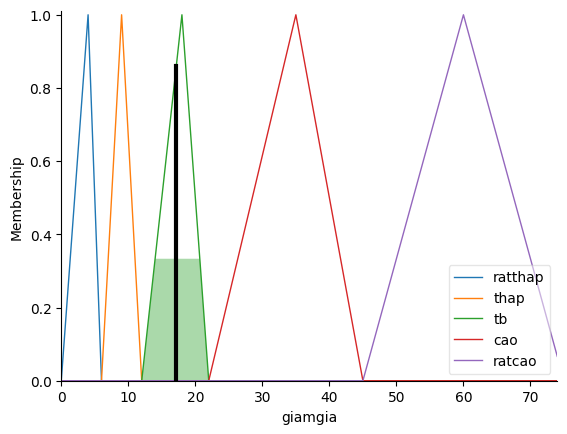

In [6]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

nhucau = ctrl.Antecedent(np.arange(0, 105, 1), 'nhucau')
uytin = ctrl.Antecedent(np.arange(1, 5.2, 0.1), 'uytin')
loinhuan = ctrl.Antecedent(np.arange(0, 105, 0.1), 'loinhuan')
muavu = ctrl.Antecedent(np.arange(0, 105, 1), 'muavu')
doithu = ctrl.Antecedent(np.arange(0, 105, 1), 'doithu')
giamgia = ctrl.Consequent(np.arange(0,75,1), 'giamgia')

uytin['thap'] = fuzz.trimf(uytin.universe,[1,1,4.2])
uytin['tb'] = fuzz.trimf(uytin.universe,[4,4.4,4.7])
uytin['cao'] = fuzz.trimf(uytin.universe,[4.6,5.1,5.1])

nhucau['thap'] = fuzz.trimf(nhucau.universe,[0,0,35])
nhucau['tb'] = fuzz.trimf(nhucau.universe,[35,55,75])
nhucau['cao'] = fuzz.trimf(nhucau.universe,[75,105,105])

loinhuan['thap'] = fuzz.trimf(loinhuan.universe,[0,0,35])
loinhuan['tb'] = fuzz.trimf(loinhuan.universe,[35,55,75])
loinhuan['cao'] = fuzz.trimf(loinhuan.universe,[75,105,105])

muavu['thap'] = fuzz.trimf(muavu.universe,[0,0,12])
muavu['tb'] = fuzz.trimf(muavu.universe,[12,45,75])
muavu['cao'] = fuzz.trimf(muavu.universe,[55,85,105])

doithu['thap'] = fuzz.trimf(doithu.universe,[0,0,35])
doithu['tb'] = fuzz.trimf(doithu.universe,[35,55,75])
doithu['cao'] = fuzz.trimf(doithu.universe,[75,105,105])

giamgia['ratthap'] = fuzz.trimf(giamgia.universe,[0,4,6])
giamgia['thap'] = fuzz.trimf(giamgia.universe,[6,9,12])
giamgia['tb'] = fuzz.trimf(giamgia.universe,[12,18,22])
giamgia['cao'] = fuzz.trimf(giamgia.universe,[22,35,45])
giamgia['ratcao'] = fuzz.trimf(giamgia.universe,[45,60,75])

rule1 = ctrl.Rule(nhucau['cao'] & doithu['thap'] & loinhuan['thap'], giamgia['ratthap'])
rule2 = ctrl.Rule(nhucau['thap'] & doithu['cao'] & loinhuan['cao'], giamgia['cao'])
rule3 = ctrl.Rule(uytin['cao'] & loinhuan['tb'] & muavu['cao'], giamgia['tb'])
rule4 = ctrl.Rule(doithu['cao'] & muavu['cao'] & loinhuan['cao'], giamgia['ratthap'])
rule5 = ctrl.Rule(uytin['thap'] & loinhuan['thap'] & nhucau['tb'], giamgia['tb'])
rule6 = ctrl.Rule(muavu['thap'] & nhucau['cao'] & doithu['thap'], giamgia['ratthap'])
rule7 = ctrl.Rule(doithu['tb'] & loinhuan['cao'] & muavu['tb'], giamgia['tb'])

hethongctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7])
hethong = ctrl.ControlSystemSimulation(hethongctrl)

hethong.input['uytin'] = 4.3
hethong.input['nhucau'] = 85
hethong.input['loinhuan'] = 90
hethong.input['muavu'] = 65
hethong.input['doithu'] = 55

hethong.compute()
print(hethong.output['giamgia'])

giamgia.view(sim=hethong)

91.28217821782178
55.00000000000001


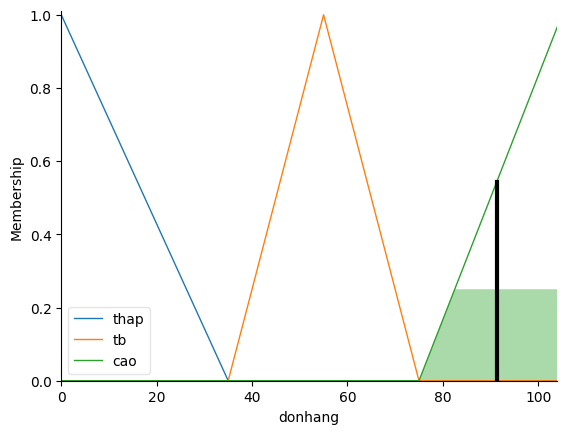

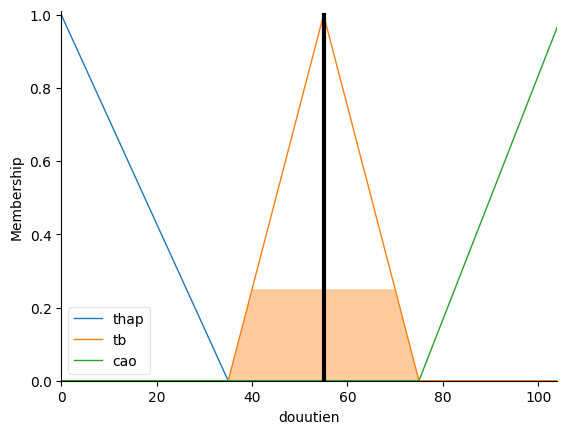

In [7]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

matdo = ctrl.Antecedent(np.arange(0, 105, 1), 'matdo')
khancap = ctrl.Antecedent(np.arange(0, 12, 1), 'khancap')
loinhuan = ctrl.Antecedent(np.arange(0, 105, 0.1), 'loinhuan')
tailuong = ctrl.Antecedent(np.arange(0, 105, 1), 'tailuong')
giaothong = ctrl.Antecedent(np.arange(0, 12, 1), 'giaothong')

douutien = ctrl.Consequent(np.arange(0,105,1), 'douutien')
donhang = ctrl.Consequent(np.arange(0,105,1), 'donhang')

matdo['thap'] = fuzz.trimf(matdo.universe,[0,0,35])
matdo['tb'] = fuzz.trimf(matdo.universe,[35,55,75])
matdo['cao'] = fuzz.trimf(matdo.universe,[75,105,105])

khancap['thap'] = fuzz.trimf(khancap.universe,[0,0,4])
khancap['tb'] = fuzz.trimf(khancap.universe,[3,6,9])
khancap['cao'] = fuzz.trimf(khancap.universe,[8,11,11])

loinhuan['thap'] = fuzz.trimf(loinhuan.universe,[0,0,35])
loinhuan['tb'] = fuzz.trimf(loinhuan.universe,[35,55,75])
loinhuan['cao'] = fuzz.trimf(loinhuan.universe,[75,105,105])

tailuong['thap'] = fuzz.trimf(tailuong.universe,[0,0,35])
tailuong['tb'] = fuzz.trimf(tailuong.universe,[35,55,75])
tailuong['cao'] = fuzz.trimf(tailuong.universe,[75,105,105])

giaothong['thap'] = fuzz.trimf(giaothong.universe,[0,0,4])
giaothong['tb'] = fuzz.trimf(giaothong.universe,[3,6,9])
giaothong['cao'] = fuzz.trimf(giaothong.universe,[8,11,11])

douutien['thap'] = fuzz.trimf(douutien.universe,[0,0,35])
douutien['tb'] = fuzz.trimf(douutien.universe,[35,55,75])
douutien['cao'] = fuzz.trimf(douutien.universe,[75,105,105])

donhang['thap'] = fuzz.trimf(donhang.universe,[0,0,35])
donhang['tb'] = fuzz.trimf(donhang.universe,[35,55,75])
donhang['cao'] = fuzz.trimf(donhang.universe,[75,105,105])

rule1 = ctrl.Rule(matdo['cao'] & giaothong['thap'] & tailuong['thap'], donhang['cao'])
rule2 = ctrl.Rule(matdo['tb'] & giaothong['cao'] & khancap['tb'], donhang['thap'])
rule3 = ctrl.Rule(matdo['cao'] & loinhuan['tb'] & tailuong['cao'], donhang['tb'])
rule4 = ctrl.Rule(giaothong['tb'] & matdo['thap'] & khancap['cao'], donhang['thap'])
rule5 = ctrl.Rule(khancap['cao'] & loinhuan['cao'] & giaothong['cao'], donhang['thap'])
rule6 = ctrl.Rule(khancap['cao'] & loinhuan['cao'], douutien['cao'])
rule7 = ctrl.Rule(giaothong['tb'] & khancap['tb'], douutien['tb'])
rule8 = ctrl.Rule(giaothong['thap'] & khancap['tb'], douutien['tb'])
rule9 = ctrl.Rule(khancap['thap'] & loinhuan['thap'] & matdo['cao'], douutien['thap'])

hethongctrl = ctrl.ControlSystem([
    rule1,rule2,rule3,rule4,rule5,
    rule6,rule7,rule8,rule9
])

hethong = ctrl.ControlSystemSimulation(hethongctrl)

hethong.input['matdo'] = 85
hethong.input['khancap'] = 7
hethong.input['loinhuan'] = 60
hethong.input['tailuong'] = 25
hethong.input['giaothong'] = 3

hethong.compute()

print(hethong.output['donhang'])
print(hethong.output['douutien'])

donhang.view(sim=hethong)
douutien.view(sim=hethong)